# Chapter 3: Tabular Data with Pandas

*Part I — Scientific Python for Researchers*

## Learning Objectives

By the end of this chapter you will be able to:

- Work confidently with Series and DataFrames
- Index, filter, group, and aggregate tabular data
- Combine two tables with `merge`
- Apply vectorized operations instead of Python loops

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Series and DataFrames

In Chapter 2, you stored a handful of cities in a plain Python dictionary — a perfectly good tool for five records, kept in memory, with no built-in way to sort, filter, or summarize them beyond writing your own loops. `pandas` exists for exactly the moment your dictionary grows into a dataset: it gives you two data structures, `Series` and `DataFrame`, purpose-built for exactly that kind of tabular, labeled data.

Think of a `DataFrame` as a spreadsheet that has been fully digitized: rows and columns, each column with its own name and data type, and — crucially — a row **index** that lets pandas find any row instantly instead of scanning through it one by one. A `Series` is a single column of that spreadsheet on its own: one-dimensional, but still carrying the row index with it, which is what separates it from a plain NumPy array.

Let's put this to work with a real dataset: country-level population and GDP figures bundled with this book (the same file Chapter 1 loaded with `geopandas`, here without the geometry column).

In [2]:
df = pd.read_csv("world_data.csv")
df.head()

,country,continent,population,gdp
0,Fiji,Oceania,889953.0,5496
1,Tanzania,Africa,58005463.0,63177
2,W. Sahara,Africa,603253.0,907
3,Canada,North America,37589262.0,1736425
4,United States of America,North America,328239523.0,21433226


`df.head()` prints the first five rows by default — pass a number, e.g. `df.head(10)`, to see more. Its counterpart, `df.tail()`, does the same from the end of the table. Both are the first thing you should run on any new dataset, simply to confirm it loaded the way you expect.

Before going further, `.info()` is worth knowing by heart: it gives you the shape of the DataFrame, the data type of every column, and — very usefully — a non-null count per column, which is the fastest way to spot missing data.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     177 non-null    str    
 1   continent   177 non-null    str    
 2   population  177 non-null    float64
 3   gdp         177 non-null    int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 5.7 KB


<div class="admonition info">
<p class="admonition-title">Did you know?</p>
<p>A <strong>method</strong> is a function attached to an object — <code>df.head()</code> only makes sense because <code>df</code> is a DataFrame. A plain function like <code>len(df)</code> takes its arguments inside the parentheses instead, with no object of its own to belong to.</p>
</div>

## Indexing and Selection

Selecting a single column returns a `Series` — you can use bracket notation, `df['country']`, or, when the column name has no spaces, dot notation, `df.country`. Both are common in real code; bracket notation is the safer default since it also works for column names pandas would otherwise mistake for a method.

In [4]:
df['country'].head()

0                        Fiji
1                    Tanzania
2                   W. Sahara
3                      Canada
4    United States of America
Name: country, dtype: str

Selecting *rows* works differently, and this is where most beginners trip up. By default, pandas gives every DataFrame an integer row index starting at 0 — note that this is **not** the same as a spreadsheet's row numbers, which conventionally start at 1 and reserve row 1 for the header. Row `0` in a DataFrame is already your first data record.

To select rows by their position, use `.iloc[]`:

In [5]:
df.iloc[2]   # the third row, by position

country       W. Sahara
continent        Africa
population     603253.0
gdp                 907
Name: 2, dtype: object

The default integer index is fine, but it carries no meaning of its own. Since no two countries share a name in this dataset, it makes more sense to use `country` itself as the index — then a row can be looked up by name instead of by a position you'd have to already know:

In [6]:
df.set_index('country', inplace=True)
df.head()

,continent,population,gdp
country,,,
Fiji,Oceania,889953.0,5496
Tanzania,Africa,58005463.0,63177
W. Sahara,Africa,603253.0,907
Canada,North America,37589262.0,1736425
United States of America,North America,328239523.0,21433226


<div class="admonition warning">
<p class="admonition-title">Watch out</p>
<p><code>inplace=True</code> modifies <code>df</code> directly and returns nothing. Leave it out (the default is <code>inplace=False</code>) and the method instead returns a new DataFrame with the change applied, leaving the original untouched — usually the safer choice, since it doesn't destroy your original data if you got the operation wrong.</p>
</div>

Now that `country` is the index rather than a column, look it up by label with `.loc[]` — note the square brackets, not parentheses, which is the syntax both `.loc` and `.iloc` share:

In [7]:
df.loc['Brazil']

continent     South America
population      211049527.0
gdp                 1839758
Name: Brazil, dtype: object

## Filtering and Boolean Masks

Selecting rows that satisfy a condition — every country in a given continent, say — is one of the most common operations in tabular data. `.query()` reads almost like a sentence and is the clearest way to write it:

In [8]:
south_america = df.query('continent == "South America"')
south_america

,continent,population,gdp
country,,,
Argentina,South America,44938712.0,445445
Chile,South America,18952038.0,282318
Falkland Is.,South America,3398.0,282
Uruguay,South America,3461734.0,56045
Brazil,South America,211049527.0,1839758
Bolivia,South America,11513100.0,40895
Peru,South America,32510453.0,226848
Colombia,South America,50339443.0,323615
Venezuela,South America,28515829.0,482359


The result of a query is itself a full DataFrame, so it can be filtered, indexed, or queried again. Selecting more than one column from it returns another DataFrame; selecting exactly one collapses it down to a `Series`, which is how you can tell the two structures apart in practice:

In [9]:
subset = south_america[['population', 'gdp']]
print(type(subset))

population = south_america['population']
print(type(population))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


## GroupBy and Aggregation

`.sum()`, like most pandas aggregations, works on both a `Series` and a `DataFrame`, collapsing many values into one:

In [10]:
south_america['population'].sum()

np.float64(427066661.0)

Getting to that number took two steps — filter, then sum — with an intermediate DataFrame (`south_america`) kept around only to be thrown away afterward. Once you only care about the final result, **method chaining** collapses the whole sequence into a single expression:

In [11]:
df.query('continent == "South America"')['population'].sum()

np.float64(427066661.0)

It helps to picture method chaining as a conveyor belt: the DataFrame enters at the left, and each method is a station along the belt that transforms it a little further before passing it to the next one — filter here, select a column there, aggregate at the end. Nothing is assigned to an intermediate variable; the data simply flows through the chain.

`.groupby()` is the same idea generalized to *every* group at once, instead of one continent filtered by hand. "Group by continent, then sum the GDP of each group" is written almost exactly like that:

In [12]:
gdp_by_continent = df.groupby('continent')['gdp'].sum().sort_values(ascending=False)
gdp_by_continent

continent
Asia                       32725478
North America              25075988
Europe                     21587850
South America               3852015
Africa                      2455514
Oceania                     1647113
Antarctica                      898
Seven seas (open ocean)          16
Name: gdp, dtype: int64

<div class="admonition info">
<p class="admonition-title">Did you know?</p>
<p>pandas can plot a Series directly with <code>.plot(kind=...)</code>, which is convenient for a quick look — try <code>gdp_by_continent.plot(kind="barh")</code> below. Chapter 12 comes back to visualization properly, using Matplotlib directly for full control over labels, color, and layout.</p>
</div>

<Axes: ylabel='continent'>

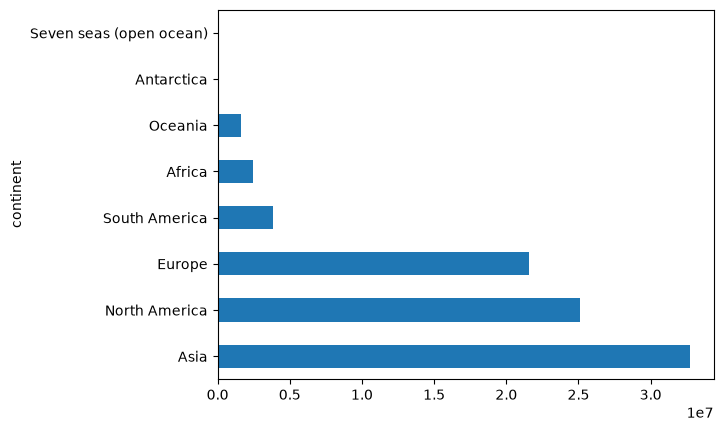

In [13]:
gdp_by_continent.plot(kind="barh")

## Merging and Joining

Real datasets rarely arrive as a single table. Suppose you also had a small table classifying each continent into the "Global North" or "Global South" — a common grouping in development economics and geography — and wanted that label attached to every one of the 177 countries in `df`. `pd.merge()` does exactly this: it joins two DataFrames on a shared key column, copying values from the smaller table across into every matching row of the larger one.

In [14]:
hemisphere_group = pd.DataFrame({
    "continent": ["Africa", "Asia", "Europe", "North America",
                  "South America", "Oceania", "Antarctica",
                  "Seven seas (open ocean)"],
    "group": ["Global South", "Global South", "Global North", "Global North",
              "Global South", "Global South", "Global South", "Global South"],
})

df_grouped = pd.merge(df.reset_index(), hemisphere_group, on="continent", how="left")
df_grouped.head()

,country,continent,population,gdp,group
0,Fiji,Oceania,889953.0,5496,Global South
1,Tanzania,Africa,58005463.0,63177,Global South
2,W. Sahara,Africa,603253.0,907,Global South
3,Canada,North America,37589262.0,1736425,Global North
4,United States of America,North America,328239523.0,21433226,Global North


Notice the merge key, `continent`, is unique in `hemisphere_group` (eight rows, one per continent) but repeats many times in `df` (177 rows, one per country) — pandas handles this automatically, copying each continent's `group` value into every country that belongs to it. This is called a **many-to-one** merge, and it is by far the most common kind you will write.

The `how="left"` argument controls what happens to rows that don't find a match: `"left"` keeps every row from `df` even if `hemisphere_group` had no matching continent (the new column would simply be `NaN`); `"inner"` (the default) would drop them instead. `"left"` is the safer default when you're enriching an existing table rather than filtering it.

## Vectorized Operations

Just like the NumPy arrays from Chapter 2, arithmetic on a pandas column applies to every row at once — no `for` loop required. Computing GDP per capita for all 177 countries is a single expression:

In [15]:
df['gdp_per_capita'] = df['gdp'] * 1000 / df['population']
df[['population', 'gdp', 'gdp_per_capita']].sort_values('gdp_per_capita', ascending=False).head()

,population,gdp,gdp_per_capita
country,,,
Antarctica,4490.0,898,200.000000
Luxembourg,619896.0,71104,114.703111
Fr. S. Antarctic Lands,140.0,16,114.285714
Falkland Is.,3398.0,282,82.989994
Switzerland,8574832.0,703082,81.993676


Under the hood, `df['gdp'] * 1000 / df['population']` is doing the same element-by-element arithmetic you saw with `np.sqrt(...)` at the end of Chapter 2 — pandas Series are built directly on top of NumPy arrays, so every vectorized trick from that chapter carries over here for free.

## Exercises

1. **Smallest and largest.** Using `df`, find the country with the smallest population and the country with the largest GDP. (Hint: `.sort_values()` and `.iloc[0]`, or look up `.idxmax()` / `.idxmin()` in the pandas documentation.)
2. **Your own filter.** Write a `.query()` that returns every country in `df` with a population under 1 million. How many are there?
3. **Group by your own rule.** Using `df_grouped` from *Merging and Joining*, compute the total population of the "Global North" versus the "Global South" with a single chained expression.
4. **A second merge.** Build a small two-row DataFrame mapping `"South America"` and `"Europe"` to a currency of your choice, and merge it onto `df` with `how="left"`. What happens to the other six continents' rows?

In [16]:
# Your code here

## Summary

### Key concepts introduced

- `Series` (one column) and `DataFrame` (many columns) as pandas' two core data structures, both built on NumPy and both carrying a row index
- `.head()`, `.tail()`, and `.info()` as the first three methods to run on any new dataset
- `.iloc[]` for position-based row access and `.loc[]` for label-based access, after `.set_index()`
- `.query()` for boolean filtering, and method chaining as a way to compose several operations without intermediate variables
- `.groupby()` for computing an aggregate per group in a single expression
- `pd.merge()` for combining two tables on a shared key, including the many-to-one case
- Vectorized column arithmetic as the pandas equivalent of the NumPy vectorization from Chapter 2

Chapter 4 picks up right where `.info()` left off: what to do about the missing, duplicated, or malformed values that a real dataset — unlike `world_data.csv` — will almost certainly contain.

## Further Reading

- Wes McKinney, *Python for Data Analysis* (O'Reilly) — written by pandas' original author; the standard reference for everything in this chapter and beyond
- pandas documentation, *User Guide* — the authoritative, continuously updated reference: <https://pandas.pydata.org/docs/user_guide/index.html>
- pandas documentation, *Merge, join, concatenate and compare* — a deeper treatment of the merge behavior introduced above: <https://pandas.pydata.org/docs/user_guide/merging.html>